In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
df = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
df.to_csv("aapl_stock.csv")
print(df.head())
print(df.shape)

/tmp/ipykernel_2331/1699368181.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  178.103668  178.955006  173.895967  174.013387  104487900
2022-01-04  175.843262  179.013730  175.275708  178.710386   99310400
2022-01-05  171.165833  176.303156  170.891843  175.755177   94537600
2022-01-06  168.308517  171.537695  167.956243  168.993491   96904000
2022-01-07  168.474854  170.402574  167.359321  169.179402   86709100
(752, 5)


In [4]:

df.columns = df.columns.get_level_values(0)
print(df.columns)
print(df.head())

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price            Close        High         Low        Open     Volume
Date                                                                 
2022-01-03  178.103668  178.955006  173.895967  174.013387  104487900
2022-01-04  175.843262  179.013730  175.275708  178.710386   99310400
2022-01-05  171.165833  176.303156  170.891843  175.755177   94537600
2022-01-06  168.308517  171.537695  167.956243  168.993491   96904000
2022-01-07  168.474854  170.402574  167.359321  169.179402   86709100


In [5]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
print(df.describe())

(752, 5)
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object
Price       Close        High         Low        Open        Volume
count  752.000000  752.000000  752.000000  752.000000  7.520000e+02
mean   175.930896  177.602215  174.054118  175.737404  6.811545e+07
std     29.379631   29.301144   29.325771   29.304615  2.834590e+07
min    123.046806  125.753403  122.210234  124.021209  2.323470e+07
25%    153.364742  155.061759  151.123559  152.832397  4.877432e+07
50%    171.176888  172.192449  169.396999  170.829562  6.224455e+07
75%    189.577999  190.982789  188.283302  189.460077  8.059140e+07
max    257.612701  258.686851  256.230269  256.787224  3.186799e+08


In [6]:
df["Daily_Return"] = df["Close"].pct_change()
df["MA_7"]  = df["Close"].rolling(window=7).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()
df["Volatility_30"] = df["Daily_Return"].rolling(window=30).std()
print(df.head(35))

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2022-01-03  178.103668  178.955006  173.895967  174.013387  104487900   
2022-01-04  175.843262  179.013730  175.275708  178.710386   99310400   
2022-01-05  171.165833  176.303156  170.891843  175.755177   94537600   
2022-01-06  168.308517  171.537695  167.956243  168.993491   96904000   
2022-01-07  168.474854  170.402574  167.359321  169.179402   86709100   
2022-01-10  168.494415  168.797760  164.560689  165.451162  106765600   
2022-01-11  171.322403  171.420248  167.153837  168.621644   76138300   
2022-01-12  171.762726  173.377307  171.067972  172.340060   74805200   
2022-01-13  168.494415  172.829330  168.102991  172.007362   84505800   
2022-01-14  169.355545  170.050299  167.418029  167.662664   80440800   
2022-01-18  166.155716  168.836900  165.774087  167.829007   90956700   
2022-01-19  162.662338  167.408253  162.378569  166

**PLOT - 1**

*Price Trend With Moving Averages*

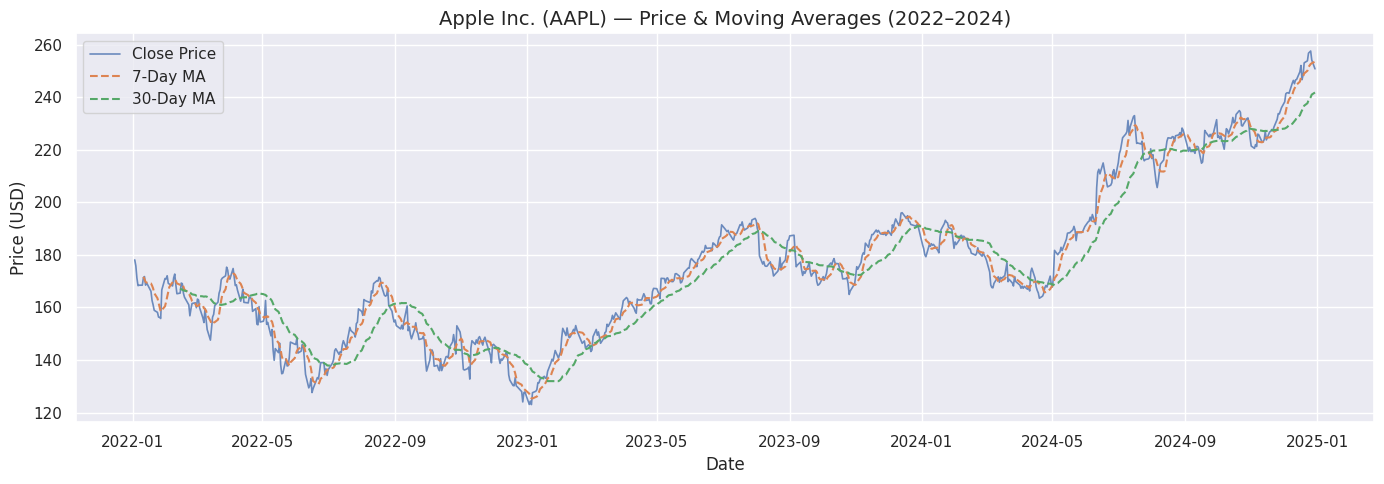

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], label="Close Price", linewidth=1.2, alpha=0.8)
plt.plot(df.index, df["MA_7"], label="7-Day MA", linewidth=1.5, linestyle="--")
plt.plot(df.index, df["MA_30"], label="30-Day MA", linewidth=1.5, linestyle="--")

plt.title("Apple Inc. (AAPL) — Price & Moving Averages (2022–2024)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("aapl_price_ma.png", dpi=150)
plt.show()

**PLOT - 2**

*Daily Returns distribution*

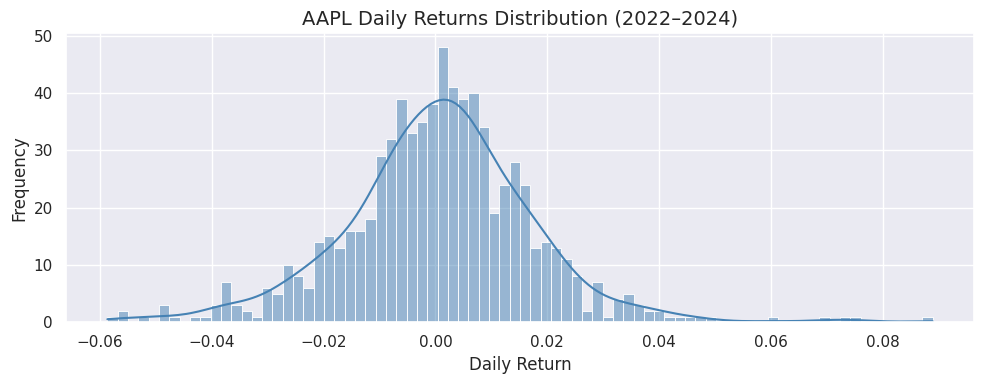

In [8]:
plt.figure(figsize=(10, 4))
sns.histplot(df["Daily_Return"].dropna(), bins=80, kde=True, color="steelblue")

plt.title("AAPL Daily Returns Distribution (2022–2024)", fontsize=14)
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("aapl_returns_dist.png", dpi=150)
plt.show()

**PLOT - 3**

*Rolling Volatility over time*

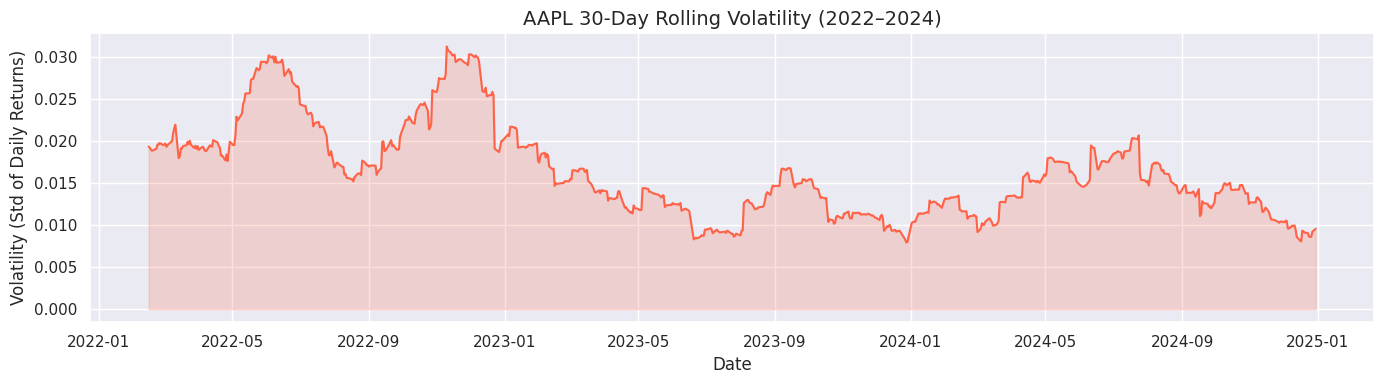

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Volatility_30"], color="tomato", linewidth=1.5)
plt.fill_between(df.index, df["Volatility_30"], alpha=0.2, color="tomato")

plt.title("AAPL 30-Day Rolling Volatility (2022–2024)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Volatility (Std of Daily Returns)")
plt.tight_layout()
plt.savefig("aapl_volatility.png", dpi=150)
plt.show()

**MONTHLY RETURNS HEATMAP**

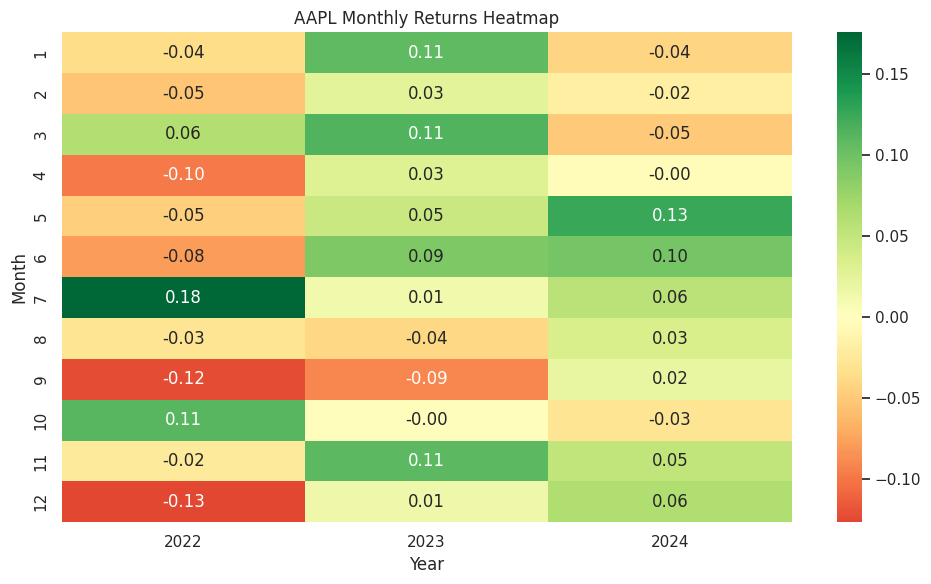

In [11]:
df["Year"] = df.index.year
df["Month"] = df.index.month

monthly_returns = df.groupby(["Year", "Month"])["Daily_Return"].sum().unstack(0)

plt.figure(figsize=(10, 6))
sns.heatmap(monthly_returns, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("AAPL Monthly Returns Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

**Sharpe Ratio (Risk-Adjusted Return)**

*How much return you are getting per unit of rish you are taking?*

In [12]:
risk_free_rate = 0.05 / 252  # ~5% annual, converted to daily

excess_returns = df["Daily_Return"] - risk_free_rate
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * (252 ** 0.5)

print(f"AAPL Sharpe Ratio (2022–2024): {sharpe_ratio:.2f}")

AAPL Sharpe Ratio (2022–2024): 0.37


**Drawdown Analysis**

*Measures how far the stock fell from its peak at any point. Shows the worst "pain period".*

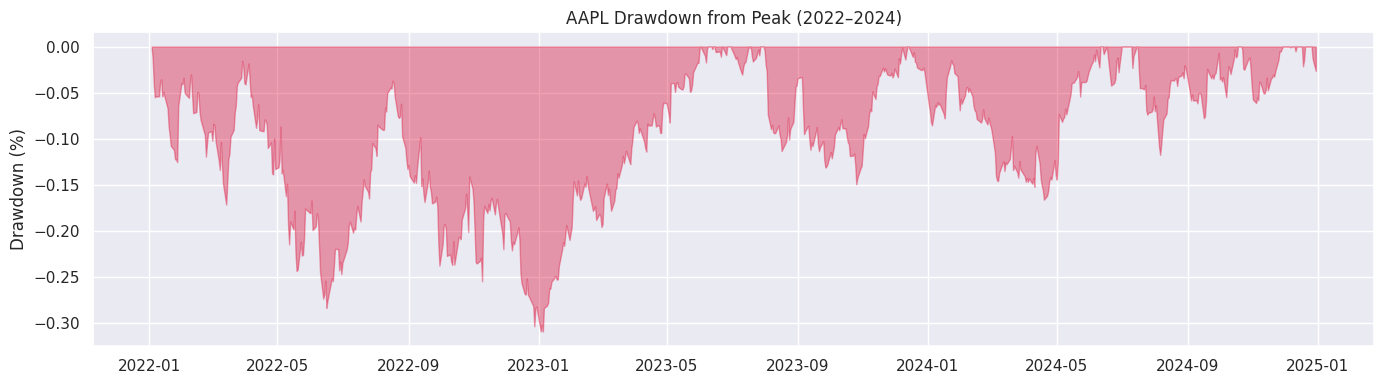

Max Drawdown: -30.91%


In [13]:
rolling_max = df["Close"].cummax()
drawdown = (df["Close"] - rolling_max) / rolling_max

plt.figure(figsize=(14, 4))
plt.fill_between(df.index, drawdown, color="crimson", alpha=0.4)
plt.title("AAPL Drawdown from Peak (2022–2024)")
plt.ylabel("Drawdown (%)")
plt.tight_layout()
plt.show()

print(f"Max Drawdown: {drawdown.min():.2%}")

**Volume vs Price Movement**


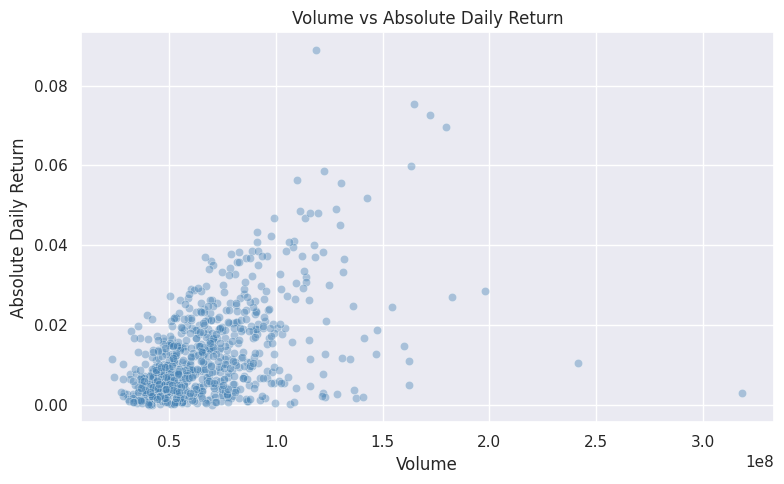

Correlation between Volume and Price Movement: 0.49


In [14]:
df["Abs_Return"] = df["Daily_Return"].abs()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Volume", y="Abs_Return", alpha=0.4, color="steelblue")
plt.title("Volume vs Absolute Daily Return")
plt.xlabel("Volume")
plt.ylabel("Absolute Daily Return")
plt.tight_layout()
plt.show()

corr = df["Volume"].corr(df["Abs_Return"])
print(f"Correlation between Volume and Price Movement: {corr:.2f}")